## **Part A: The Foundation (Standard Workflow)**

## **Task 1: Data Preparation**

* **Dataset:** Playing cards dataset **(53 classes)**
* **Structure:** Organise into class and folders
* **Split:** Provided with **Training** and **Validation** candidates. Seperate Test will be provided for evaluation.

In [1]:
print('='*50)
print("Part A - TASK 1: Import Libraries")
print('='*50)
print()

#----Core Libraries----
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import random

#----Keras: Libraries----
from keras.models import Sequential
from keras.layers import (Conv2D, Flatten, Dense)

#----Scikit-Learn Libraries----
from sklearn.metrics import classification_report

print('='*10)
print("Libraries Loaded!")
print('='*10)

Part A - TASK 1: Import Libraries


Libraries Loaded!


In [2]:
#Set file path with a variable set name
TRAIN_DIR = './project_data/train'
VALID_DIR = './project_data/valid'
TEST_DIR = './project_data/test'

print("File paths set!")

File paths set!


In [3]:
#To extract 53 classes of the folder (Train, Valid, Test)
class_names = sorted(os.listdir(TRAIN_DIR))
num_classes = len(class_names)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print(f"Found: {num_classes} classes")
print(f"First 5 classes: {class_names[:5]}")

Found: 53 classes
First 5 classes: ['ace of clubs', 'ace of diamonds', 'ace of hearts', 'ace of spades', 'eight of clubs']


## **Task 2: Preprocessing**

In [4]:
#Custom Load Data
def load_data(directory, class_to_idx, image_size=(64, 64)):
    X_values = []
    y_values = []

    folder_name = os.path.basename(directory)

    folders = sorted([f for f in os.listdir(directory) if not f.startswith('.')])
    
    #Header
    print('-'*50)
    print(f"Found {folder_name} - Folders: {len(folders)} class folders inside")
    print('-'*50)
    for each_folder in folders:
        sub_path = os.path.join(directory, each_folder)
        
        if not os.path.isdir(sub_path):
            continue

        label = class_to_idx[each_folder]
        print(f"Processing folders: {each_folder} -> Label: {label}")
    
        for each_image in sorted(os.listdir(sub_path)):
            if not each_image.startswith('.'):
                full_path = os.path.join(sub_path, each_image)
                
                #image editing
                image = cv2.imread(full_path)
                if image is None:
                    continue
                image = cv2.resize(image, image_size)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                
                X_values.append(image)
                y_values.append(label)
    
    
    #Footer
    print('='*50)
    print(f'{folder_name} Folder - COMPLETE -- {len(X_values)} images loaded')
    print('='*50)
    print()

    #Conversion of input into arrays            
    X_array = np.array(X_values)
    y_array = np.array(y_values)

    #Output
    return X_array, y_array

In [5]:
print('='*50)
print("Part A - TASK 2: Preprocessing")
print('='*50)
print()

#Load the Train File Directory
print('='*50)
print("Loading the Train File")
print('='*50)
print()

X_train, y_train = load_data(TRAIN_DIR, class_to_idx, image_size=(64,64))

#Load the Valid File Directory
print('='*50)
print("Loading the Valid File")
print('='*50)
print()

X_val, y_val = load_data(VALID_DIR, class_to_idx, image_size=(64,64))

#Load the Test File Directory
print('='*50)
print("Loading the Test File")
print('='*50)
print()

X_test, y_test = load_data(TEST_DIR, class_to_idx, image_size=(64,64))

print(f"X_train Shape: {X_train.shape}")

Part A - TASK 2: Preprocessing

Loading the Train File

--------------------------------------------------
Found train - Folders: 53 class folders inside
--------------------------------------------------
Processing folders: ace of clubs -> Label: 0
Processing folders: ace of diamonds -> Label: 1
Processing folders: ace of hearts -> Label: 2
Processing folders: ace of spades -> Label: 3
Processing folders: eight of clubs -> Label: 4
Processing folders: eight of diamonds -> Label: 5
Processing folders: eight of hearts -> Label: 6
Processing folders: eight of spades -> Label: 7
Processing folders: five of clubs -> Label: 8
Processing folders: five of diamonds -> Label: 9
Processing folders: five of hearts -> Label: 10
Processing folders: five of spades -> Label: 11
Processing folders: four of clubs -> Label: 12
Processing folders: four of diamonds -> Label: 13
Processing folders: four of hearts -> Label: 14
Processing folders: four of spades -> Label: 15
Processing folders: jack of clubs

## **Task 3: Visualization**

Part A - TASK 3: Visualization
--------------------------------------------------
Displaying 20 random samples from X_train


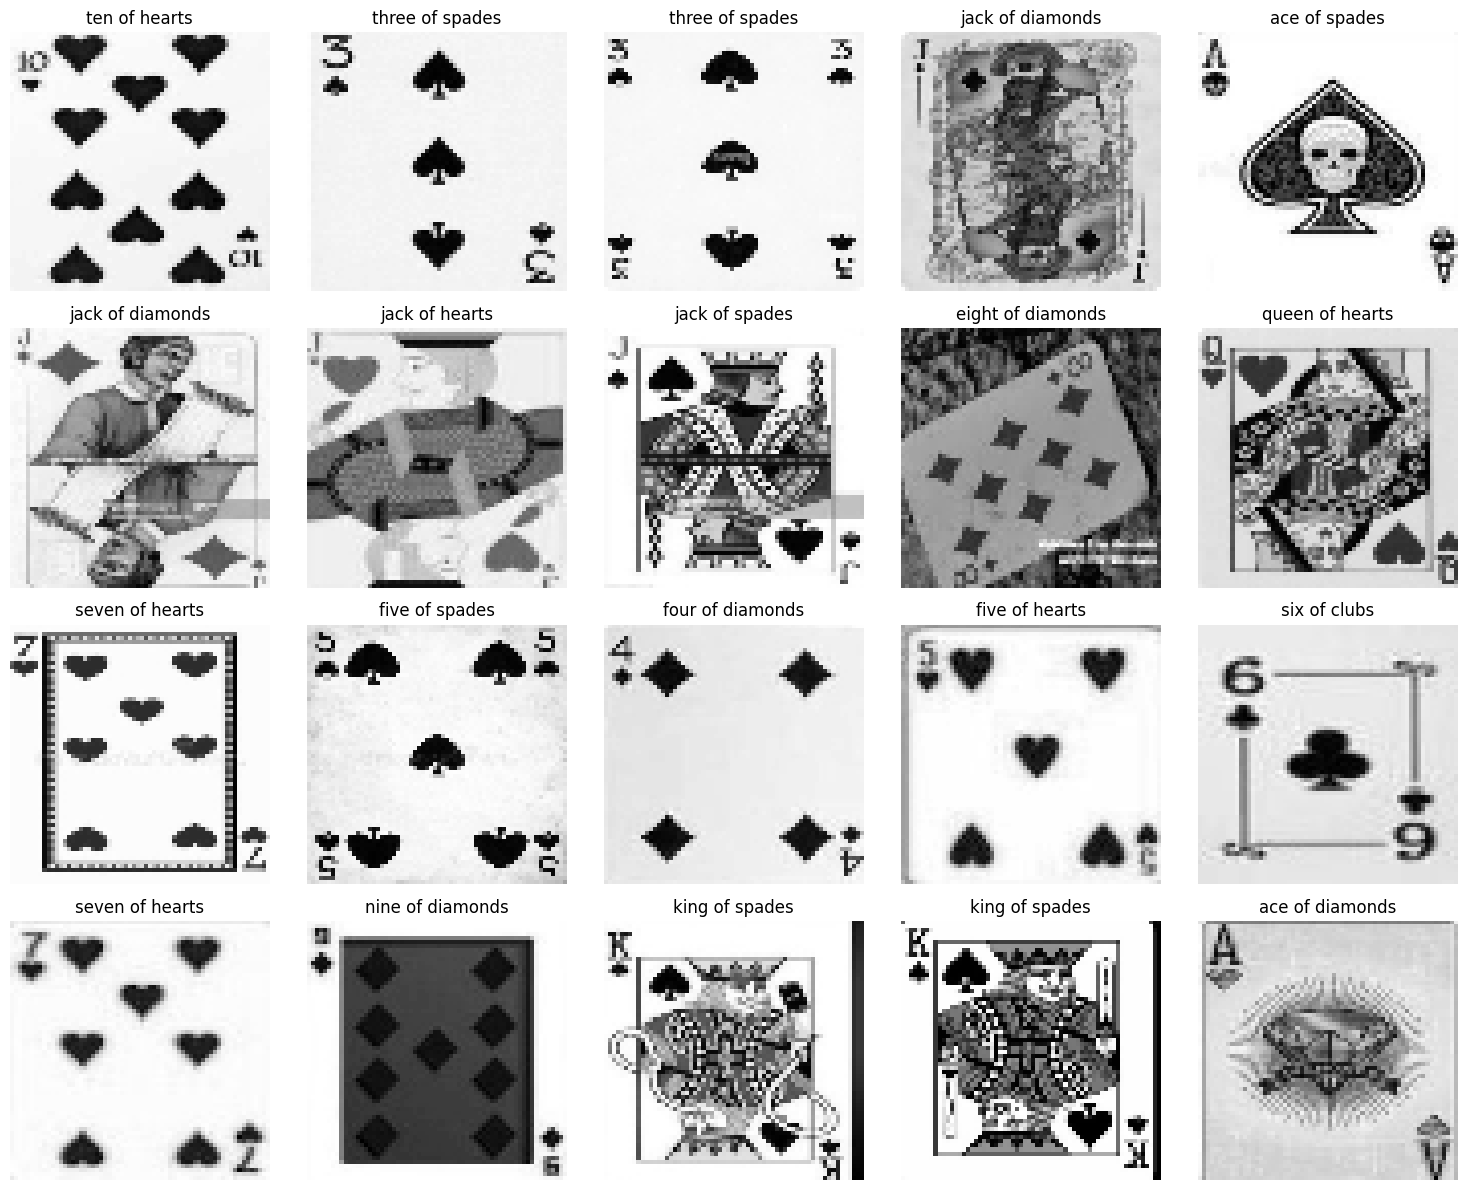

Visualization completed!


In [6]:
print('='*50)
print("Part A - TASK 3: Visualization")
print('-'*50)
print("Displaying 20 random samples from X_train")
print('='*50)

idx_to_class = {idx: name for name, idx in class_to_idx.items()}

#Randomly pick 20 samples from X_train
random_index = random.sample(range(len(X_train)), 20)


plt.figure(figsize=(15,12))

for i, idx in enumerate(random_index):
    plt.subplot(4, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(idx_to_class[y_train[idx]])
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Visualization completed!")

## **Task 4: Normalization & Splits**

* **Pre-processing:** Scale pixels to **0-1** and **reshape to 4D Tensor**
* **Splitting:** Create Train, Val, Test Split from the data

In [7]:
print('='*50)
print("Part A - TASK 4: Normalization & Reshaping")
print('='*50)
print()
print('='*50)
print(f"Before Normalization -- Pixel Range: {X_train.min()} to {X_train.max()}")
print()

X_train_norm = X_train / 255
X_val_norm = X_val / 255
X_test_norm = X_test / 255

print(f"After Normalization -- Pixel Range: {X_train_norm.min():.1f} to {X_train_norm.max():.1f}")
print('='*50)
print()

print('='*50)
print("Reshape to 4D Tensor")
print('='*50)
print()

X_train_tensor = X_train_norm.reshape(-1, 64, 64, 1)
X_val_tensor = X_val_norm.reshape(-1, 64, 64, 1)
X_test_tensor = X_test_norm.reshape(-1, 64, 64, 1)

print("Normalization & Reshaping to 4D Tensor completed!")

Part A - TASK 4: Normalization & Reshaping

Before Normalization -- Pixel Range: 0 to 255

After Normalization -- Pixel Range: 0.0 to 1.0

Reshape to 4D Tensor

Normalization & Reshaping to 4D Tensor completed!


## **Task 5: CNN Modeling**

* **Architecture**
* **Training**

In [8]:
print('='*50)
print("Part A - TASK 5: CNN Modeling Architecture")
print('='*50)
print()

num_class = 53

cnn_model = Sequential()

cnn_model.add(Conv2D(filters=32, kernel_size=(3, 3), strides=1, padding='same', activation='relu', input_shape=(64, 64, 1)))

cnn_model.add(Flatten())

cnn_model.add(Dense(num_class, activation='softmax'))

cnn_model.summary()

print("CNN Model created!")

Part A - TASK 5: CNN Modeling Architecture


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        320       
                                                                 
 flatten (Flatten)           (None, 131072)            0         
                                                                 
 dense (Dense)               (None, 53)                6946869   
                                                                 
Total params: 6947189 (26.50 MB)
Trainable params: 6947189 (26.50 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
CNN Model created!


In [ ]:
cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("CNN Model compiled & ready for training")

history = cnn_model.fit(X_train_tensor, y_train, epochs = 10, validation_data=(X_val_tensor, y_val), verbose=1)

print("Training Completed!")


CNN Model compiled & ready for training
Epoch 1/10


239/239 [==============================] - 7s 27ms/step - loss: 3.4578 - accuracy: 0.2581 - val_loss: 1.9324 - val_accuracy: 0.5283
Epoch 2/10
239/239 [==============================] - 6s 27ms/step - loss: 1.1160 - accuracy: 0.7379 - val_loss: 1.6546 - val_accuracy: 0.5811
Epoch 3/10
239/239 [==============================] - 6s 26ms/step - loss: 0.4074 - accuracy: 0.9242 - val_loss: 1.6978 - val_accuracy: 0.6264
Epoch 4/10
239/239 [==============================] - 6s 26ms/step - loss: 0.1785 - accuracy: 0.9721 - val_loss: 1.7750 - val_accuracy: 0.6113
Epoch 5/10
239/239 [==============================] - 6s 26ms/step - loss: 0.1037 - accuracy: 0.9871 - val_loss: 1.7962 - val_accuracy: 0.6415
Epoch 6/10
239/239 [==============================] - 6s 25ms/step - loss: 0.0703 - accuracy: 0.9921 - val_loss: 1.8670 - val_accuracy: 0.6038
Epoch 7/10
239/239 [==============================] - 6s 26ms/step - loss: 0.0566 - accuracy: 0.993

## **Task 6: Evaluation**

* **Curves:** Show Loss and Accuracy Curves
* **Testing:** Testing on Test Set and Classification Report

Part A - TASK 6: Loss Curves


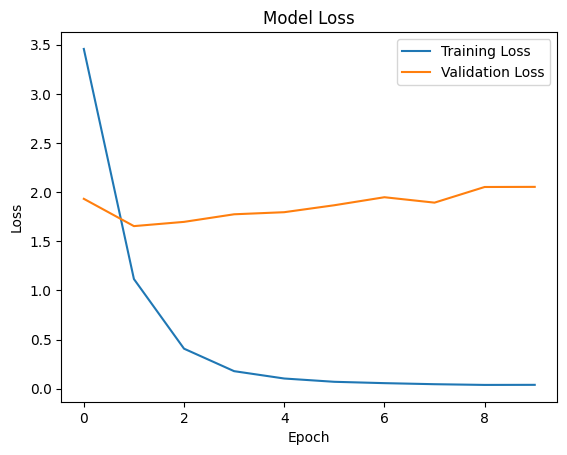

In [10]:
print('='*50)
print("Part A - TASK 6: Loss Curves")
print('='*50)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Part A - TASK 6: Accuracy Curves


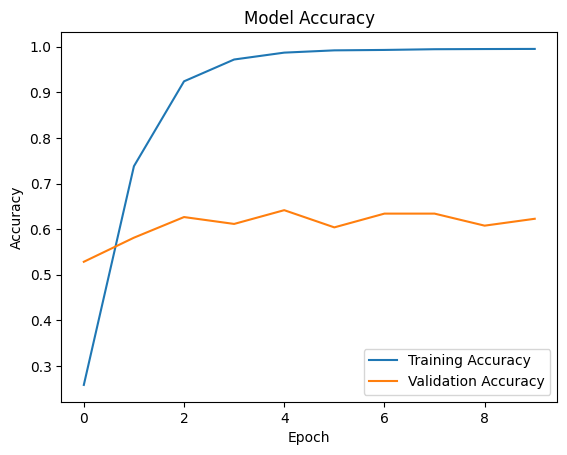

In [11]:
print('='*50)
print("Part A - TASK 6: Accuracy Curves")
print('='*50)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [12]:
print('='*50)
print("Part A - TASK 6: Prediction")
print('='*50)
print()

y_pred = cnn_model.predict(X_test_tensor).argmax(axis=1)

print(f"Converted Labels: {y_pred[:5]}")

Part A - TASK 6: Prediction

9/9 [==============================] - 0s 11ms/step
Converted Labels: [32  0  0  0  0]


In [13]:
print('='*50)
print("Part A - TASK 6: Classification Report")
print('='*50)
print()

print(classification_report(y_true=y_test, y_pred=y_pred))

print("Classification Report completed!")
print("Evaluation completed!")

Part A - TASK 6: Classification Report

              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       1.00      0.60      0.75         5
           2       0.57      0.80      0.67         5
           3       0.33      0.80      0.47         5
           4       0.71      1.00      0.83         5
           5       0.44      0.80      0.57         5
           6       0.60      0.60      0.60         5
           7       0.67      0.40      0.50         5
           8       0.50      0.60      0.55         5
           9       0.38      0.60      0.46         5
          10       1.00      0.60      0.75         5
          11       1.00      0.40      0.57         5
          12       0.50      0.60      0.55         5
          13       0.67      0.80      0.73         5
          14       1.00      0.60      0.75         5
          15       0.33      0.40      0.36         5
          16       0.80      0.80      0.